# Tasks 2: GNN on Music Structure Graphs

## 0. Setup — install dependencies

In [ ]:
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install -q torch_geometric
!pip install -q transformers datasets huggingface_hub librosa scikit-learn matplotlib seaborn joblib soxr tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 46.8 MB/s eta 0:00:00


In [ ]:
import os, re, math, json, random, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

import librosa
from datasets import load_dataset
from collections import Counter, defaultdict

from transformers import AutoTokenizer, AutoModel

from torch_geometric.nn import SAGEConv, global_mean_pool, global_max_pool
from torch_geometric.data import Data, Batch

from sklearn.metrics import f1_score, average_precision_score, accuracy_score, confusion_matrix
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

BERT_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(BERT_NAME)

USE_AMP = DEVICE.type == "cuda"

os.makedirs("results/plots", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)

Using device: cuda


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
def load_musiccaps(top_k_tags=15):
    ds = load_dataset("google/MusicCaps", split="train")

    counter = Counter()
    parsed_aspects = []
    for row in ds:
        aspects = [a.strip().lower() for a in row["aspect_list"].strip("[]").replace("'", "").split(",") if a.strip()]
        parsed_aspects.append(aspects)
        counter.update(aspects)
    vocab = [t for t, _ in counter.most_common(top_k_tags)]
    tag2idx = {t: i for i, t in enumerate(vocab)}

    examples = []
    for row, aspects in zip(ds, parsed_aspects):
        labels = np.zeros(len(vocab), dtype=np.float32)
        for a in aspects:
            if a in tag2idx:
                labels[tag2idx[a]] = 1.0
        if labels.sum() > 0:
            examples.append({"text": row["caption"], "labels": labels, "aspects": aspects})
    return examples, vocab, ds

tag_examples, tag_vocab, musiccaps_ds = load_musiccaps(top_k_tags=15)
print(f"Loaded {len(tag_examples)} caption examples, {len(tag_vocab)} tags")
print("Tags:", tag_vocab)

README.md:   0%|          | 0.00/5.06k [00:00<?, ?B/s]

musiccaps-public.csv: reconstructing file:   0%|          |  0.00B / 2.94MB            

musiccaps-public.csv: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/5521 [00:00<?, ? examples/s]

Loaded 4243 caption examples, 15 tags
Tags: ['low quality', 'instrumental', 'emotional', 'noisy', 'passionate', 'medium tempo', 'energetic', 'amateur recording', 'live performance', 'slow tempo', 'acoustic drums', 'fast tempo', 'mono', 'groovy', 'bass guitar']


In [ ]:
class TagDataset(Dataset):
    def __init__(self, examples, tokenizer, max_len=128):
        self.examples = examples
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        ex = self.examples[idx]
        enc = self.tokenizer(ex["text"], truncation=True, padding="max_length",
                              max_length=self.max_len, return_tensors="pt")
        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels": torch.tensor(ex["labels"]),
        }

random.shuffle(tag_examples)
split = int(0.85 * len(tag_examples))
train_ds = TagDataset(tag_examples[:split], tokenizer)
val_ds = TagDataset(tag_examples[split:], tokenizer)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32)
print(f"Train: {len(train_ds)}  Val: {len(val_ds)}")

Train: 3606  Val: 637


## Data pipeline for Task 2

**GTZAN**: 1,000 real 30s clips, 10 balanced genres (100 clips each): blues, classical, country, disco, hiphop, jazz, metal, pop, reggae, rock.

In [ ]:
# ============================================================
# Shared configuration
# ============================================================
GENRES = ["blues", "classical", "country", "disco", "hiphop", "jazz", "metal", "pop", "reggae", "rock"]
GENRE2IDX = {g: i for i, g in enumerate(GENRES)}
NUM_CLASSES = len(GENRES)

SR = 22050
WINDOW_SEC = 3.0
GRAPH_SIM_K = 2

N_MELS = 64
MEL_FRAMES = 640
N_FFT = 1024
HOP_LENGTH = 512

CACHE_DIR = "/content/gtzan_cache"
os.makedirs(CACHE_DIR, exist_ok=True)

print("Downloading GTZAN (Parquet mirror on the HF Hub — no loading script, no external server)...")
gtzan_raw = load_dataset("danilotpnta/GTZAN_genre_classification", "gtzan", split="train")
print(f"GTZAN clips loaded: {len(gtzan_raw)}")

# This mirror stores genre as a lowercase string column, not a ClassLabel int, so normalize it.
raw_genres = sorted(set(g.strip().lower() for g in gtzan_raw["genre"]))
print("Genres found in this mirror:", raw_genres)
assert set(raw_genres) == set(GENRES), f"Unexpected genre set: {raw_genres}"

README.md:   0%|          | 0.00/923 [00:00<?, ?B/s]

gtzan/train-00000-of-00003.parquet: reconstructing file:   0%|          |  0.00B /  441MB            

gtzan/train-00000-of-00003.parquet: downloading bytes:           |  0.00B            

gtzan/train-00001-of-00003.parquet: reconstructing file:   0%|          |  0.00B /  429MB            

gtzan/train-00001-of-00003.parquet: downloading bytes:           |  0.00B            

gtzan/train-00002-of-00003.parquet: reconstructing file:   0%|          |  0.00B /  436MB            

gtzan/train-00002-of-00003.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/999 [00:00<?, ? examples/s]

GTZAN clips loaded: 999
Genres found in this mirror: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


In [ ]:
# ============================================================
# Real, independent text for Task 3: genre-matched MusicCaps captions
# ============================================================
SYNONYMS = {
    "hiphop": [r"hip[\s-]?hop", r"\brap\b"],
    "disco": [r"\bdisco\b"],
    "classical": [r"\bclassical\b"],
    "blues": [r"\bblues\b"],
    "country": [r"\bcountry\b"],
    "jazz": [r"\bjazz\b"],
    "metal": [r"\bmetal\b"],
    "pop": [r"\bpop\b"],
    "reggae": [r"\breggae\b"],
    "rock": [r"\brock\b"],
}

def build_genre_caption_bank(ds, min_pool=25):
    bank = defaultdict(list)
    all_captions = []
    for row in ds:
        text = (row["caption"] + " " + row["aspect_list"]).lower()
        all_captions.append(row["caption"])
        for genre, patterns in SYNONYMS.items():
            if any(re.search(p, text) for p in patterns):
                bank[genre].append(row["caption"])
    for genre in GENRES:
        if len(bank[genre]) < min_pool:
            fill = random.sample(all_captions, min_pool - len(bank[genre]))
            bank[genre].extend(fill)
    return bank

genre_caption_bank = build_genre_caption_bank(musiccaps_ds)
for g in GENRES:
    print(f"{g:10s}: {len(genre_caption_bank[g])} candidate real captions")

blues     : 112 candidate real captions
classical : 303 candidate real captions
country   : 165 candidate real captions
disco     : 60 candidate real captions
hiphop    : 239 candidate real captions
jazz      : 183 candidate real captions
metal     : 160 candidate real captions
pop       : 720 candidate real captions
reggae    : 95 candidate real captions
rock      : 638 candidate real captions


### Feature extraction: segment graphs + mel spectrogram (parallel, cached)

In [ ]:
def build_segment_graph(y, sr, window_sec=WINDOW_SEC, top_k=GRAPH_SIM_K):
    win_len = int(window_sec * sr)
    n_windows = len(y) // win_len
    if n_windows < 3:
        return None

    hop = 512
    y_harm = librosa.effects.harmonic(y, margin=3)          # once per clip

    S = np.abs(librosa.stft(y, n_fft=2048, hop_length=hop))
    chroma_full   = librosa.feature.chroma_stft(S=S**2, sr=sr, hop_length=hop)
    contrast_full = librosa.feature.spectral_contrast(S=S, sr=sr, hop_length=hop)
    centroid_full = librosa.feature.spectral_centroid(S=S, sr=sr, hop_length=hop)
    mfcc_full     = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13, hop_length=hop)
    rms_full      = librosa.feature.rms(y=y, hop_length=hop)
    zcr_full      = librosa.feature.zero_crossing_rate(y, hop_length=hop)

    # tonnetz needs chroma_cqt, not chroma_stft — compute it ONCE here, not per segment
    chroma_cq_full = librosa.feature.chroma_cqt(y=y_harm, sr=sr, hop_length=hop)
    tonnetz_full   = librosa.feature.tonnetz(chroma=chroma_cq_full, sr=sr)

    # librosa's feature functions pad/center slightly differently -> align to the shortest
    T = min(chroma_full.shape[1], contrast_full.shape[1], centroid_full.shape[1],
            mfcc_full.shape[1], rms_full.shape[1], zcr_full.shape[1], tonnetz_full.shape[1])
    chroma_full, contrast_full, centroid_full = chroma_full[:, :T], contrast_full[:, :T], centroid_full[:, :T]
    mfcc_full, rms_full, zcr_full, tonnetz_full = mfcc_full[:, :T], rms_full[:, :T], zcr_full[:, :T], tonnetz_full[:, :T]

    node_feats, chroma_vecs = [], []
    for i in range(n_windows):
        f0 = int(i * win_len / hop)
        f1 = max(f0 + 1, int((i + 1) * win_len / hop))
        f1 = min(f1, T)
        if f1 <= f0:
            continue

        def ms(mat):  # mean+std over this window's frame slice
            seg = mat[:, f0:f1]
            return np.concatenate([seg.mean(axis=1), seg.std(axis=1)])

        feat = np.concatenate([
            ms(chroma_full), ms(mfcc_full), ms(contrast_full), ms(tonnetz_full),
            [centroid_full[0, f0:f1].mean()], [centroid_full[0, f0:f1].std()],
            [rms_full[0, f0:f1].mean()], [rms_full[0, f0:f1].std()],
            [zcr_full[0, f0:f1].mean()], [zcr_full[0, f0:f1].std()],
        ]).astype(np.float32)

        node_feats.append(feat)
        chroma_vecs.append(chroma_full[:, f0:f1].mean(axis=1))

    if len(node_feats) < 3:
        return None

    x = np.stack(node_feats)
    chroma_mat = np.stack(chroma_vecs)
    n = x.shape[0]

    edges = set()
    for i in range(n - 1):
        edges.add((i, i + 1)); edges.add((i + 1, i))
    norm_chroma = chroma_mat / (np.linalg.norm(chroma_mat, axis=1, keepdims=True) + 1e-8)
    sim = norm_chroma @ norm_chroma.T
    np.fill_diagonal(sim, -1)
    for i in range(n):
        for j in np.argsort(sim[i])[-top_k:]:
            edges.add((i, int(j))); edges.add((int(j), i))

    edge_index = np.array(sorted(edges), dtype=np.int64).T if edges else np.zeros((2, 0), dtype=np.int64)
    return x, edge_index

In [ ]:
def build_mel(y, sr, n_mels=N_MELS, n_fft=N_FFT, hop=HOP_LENGTH, frames=MEL_FRAMES):
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels, n_fft=n_fft, hop_length=hop)
    mel_db = librosa.power_to_db(mel, ref=np.max).astype(np.float32)
    if mel_db.shape[1] < frames:
        mel_db = np.pad(mel_db, ((0, 0), (0, frames - mel_db.shape[1])))
    else:
        mel_db = mel_db[:, :frames]
    return mel_db

In [ ]:
def process_one_row(idx_row):
    idx, row = idx_row
    try:
        y = row["audio"]["array"].astype(np.float32)
        sr = row["audio"]["sampling_rate"]
        if sr != SR:
            y = librosa.resample(y, orig_sr=sr, target_sr=SR, res_type="soxr_hq")
        genre_name = row["genre"].strip().lower()

        graph = build_segment_graph(y, SR)
        if graph is None:
            return None
        x, edge_index = graph
        mel = build_mel(y, SR)

        rng = np.random.default_rng(SEED + idx)
        text = rng.choice(genre_caption_bank[genre_name])
        return {"x": x, "edge_index": edge_index, "mel": mel, "y": genre_name, "text": text}
    except Exception as e:
        print(f"  [skip idx={idx}] {e}")
        return None

CACHE_PATH = os.path.join(CACHE_DIR, f"gtzan_processed_win{WINDOW_SEC}_simk{GRAPH_SIM_K}_seed{SEED}.pt")

if os.path.exists(CACHE_PATH):
    print(f"Loading cache: {CACHE_PATH}")
    samples = torch.load(CACHE_PATH, weights_only=False)
else:
    from tqdm.auto import tqdm
    import time

    print(f"Processing {len(gtzan_raw)} clips sequentially (no multiprocessing — safer + fast enough now)...")
    t0 = time.time()
    samples = []
    for i in tqdm(range(len(gtzan_raw))):
        r = process_one_row((i, gtzan_raw[i]))
        if r is None:
            continue
        samples.append({
            "x": torch.tensor(r["x"], dtype=torch.float32),
            "edge_index": torch.tensor(r["edge_index"], dtype=torch.long),
            "mel": torch.tensor(r["mel"], dtype=torch.float32).unsqueeze(0),
            "y": r["y"],
            "y_idx": GENRE2IDX[r["y"]],
            "text": r["text"],
        })
    print(f"Processed {len(samples)} / {len(gtzan_raw)} clips in {(time.time()-t0)/60:.1f} min.")
    torch.save(samples, CACHE_PATH)

s0 = samples[0]
print("nodes:", s0["x"].shape, " edges:", s0["edge_index"].shape, " mel:", s0["mel"].shape, " label:", s0["y"])
print("Class balance:", Counter([s["y"] for s in samples]))

Processing 999 clips sequentially (no multiprocessing — safer + fast enough now)...


  0%|          | 0/999 [00:00<?, ?it/s]

Processed 999 / 999 clips in 59.1 min.
nodes: torch.Size([10, 82])  edges: torch.Size([2, 38])  mel: torch.Size([1, 64, 640])  label: blues
Class balance: Counter({'blues': 100, 'classical': 100, 'country': 100, 'disco': 100, 'hiphop': 100, 'metal': 100, 'pop': 100, 'reggae': 100, 'rock': 100, 'jazz': 99})


In [ ]:
# ============================================================
# Stratified train/val/test split (70/15/15), reused for Task 2 & 3
# ============================================================
class GTZANDataset(Dataset):
    def __init__(self, samples):
        self.samples = samples
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        return self.samples[idx]

full_ds = GTZANDataset(samples)
all_idx = list(range(len(full_ds)))
all_labels = [s["y_idx"] for s in samples]

train_idx, temp_idx = train_test_split(all_idx, test_size=0.30, stratify=all_labels, random_state=SEED)
temp_labels = [all_labels[i] for i in temp_idx]
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=temp_labels, random_state=SEED)

train_gtzan = Subset(full_ds, train_idx)
val_gtzan = Subset(full_ds, val_idx)
test_gtzan = Subset(full_ds, test_idx)

print(f"Train: {len(train_gtzan)}  Val: {len(val_gtzan)}  Test: {len(test_gtzan)}")

Train: 699  Val: 150  Test: 150


## GraphSAGE vs CNN on GTZAN genre graphs

- **GNN:** 3-layer GraphSAGE over 3-second segment graphs (82-D acoustic node features:
  chroma + MFCC + spectral contrast + tonnetz, mean+std), temporal + top-2 chroma-similarity
  edges, mean+max pooling, single-label 10-way softmax head.
- **CNN:** 4-block conv net over the same clip's fixed 64×640 log-mel spectrogram.
- Both trained with `CrossEntropyLoss` (single-label, balanced classes — no class weighting
  needed), AdamW, cosine LR schedule, early stopping on validation accuracy, mixed precision.

In [ ]:
def graph_collate(batch):
    graphs = [Data(x=b["x"], edge_index=b["edge_index"]) for b in batch]
    return (
        Batch.from_data_list(graphs),
        torch.stack([b["mel"] for b in batch]),
        torch.tensor([b["y_idx"] for b in batch], dtype=torch.long),
    )

BATCH_SIZE = 32
train_gloader = DataLoader(train_gtzan, batch_size=BATCH_SIZE, shuffle=True, collate_fn=graph_collate)
val_gloader = DataLoader(val_gtzan, batch_size=BATCH_SIZE, shuffle=False, collate_fn=graph_collate)
test_gloader = DataLoader(test_gtzan, batch_size=BATCH_SIZE, shuffle=False, collate_fn=graph_collate)

train_x = torch.cat([full_ds[i]["x"] for i in train_idx], dim=0).float()
feature_mean = train_x.mean(dim=0).to(DEVICE)
feature_std = train_x.std(dim=0).clamp_min(1e-6).to(DEVICE)
del train_x

mel_train = torch.stack([full_ds[i]["mel"] for i in train_idx]).float()
mel_mean = mel_train.mean().to(DEVICE)
mel_std = mel_train.std().clamp_min(1e-6).to(DEVICE)
del mel_train
print("Node feature dim:", len(feature_mean))

Node feature dim: 82


In [ ]:
class Task2GraphEncoder(nn.Module):
    def __init__(self, in_dim=82, hidden=128, dropout=0.3):
        super().__init__()
        self.convs = nn.ModuleList([
            SAGEConv(in_dim, hidden),
            SAGEConv(hidden, hidden),
            SAGEConv(hidden, hidden),
        ])
        self.bns = nn.ModuleList([nn.BatchNorm1d(hidden) for _ in range(3)])
        self.dropout = dropout

    def forward(self, x, edge_index, batch):
        x = (x - feature_mean) / feature_std
        for conv, bn in zip(self.convs, self.bns):
            x = conv(x, edge_index)
            x = bn(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        g_mean = global_mean_pool(x, batch)
        g_max = global_max_pool(x, batch)
        return torch.cat([g_mean, g_max], dim=-1)   # [B, hidden*2]

class Task2GNNClassifier(nn.Module):
    def __init__(self, in_dim=82, hidden=128, num_classes=NUM_CLASSES, dropout=0.3):
        super().__init__()
        self.encoder = Task2GraphEncoder(in_dim, hidden, dropout)
        self.head = nn.Sequential(
            nn.Linear(hidden * 2, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, num_classes),
        )
    def forward(self, x, edge_index, batch):
        g = self.encoder(x, edge_index, batch)
        return self.head(g), g

class Task2CNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, dropout=0.3):
        super().__init__()
        def block(cin, cout):
            return nn.Sequential(
                nn.Conv2d(cin, cout, 3, padding=1), nn.BatchNorm2d(cout), nn.ReLU(),
                nn.MaxPool2d(2),
            )
        self.net = nn.Sequential(block(1, 16), block(16, 32), block(32, 64), block(64, 128))
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(128, num_classes))

    def forward(self, mel):
        mel = (mel - mel_mean) / mel_std
        z = self.net(mel)
        z = self.pool(z).flatten(1)
        return self.head(z), z

gnn_model = Task2GNNClassifier().to(DEVICE)
cnn_model = Task2CNN().to(DEVICE)

opt_gnn = torch.optim.AdamW(gnn_model.parameters(), lr=1e-3, weight_decay=1e-4)
opt_cnn = torch.optim.AdamW(cnn_model.parameters(), lr=1e-3, weight_decay=1e-4)

EPOCHS_TASK2 = 60
sched_gnn = torch.optim.lr_scheduler.CosineAnnealingLR(opt_gnn, T_max=EPOCHS_TASK2)
sched_cnn = torch.optim.lr_scheduler.CosineAnnealingLR(opt_cnn, T_max=EPOCHS_TASK2)
scaler2 = torch.cuda.amp.GradScaler(enabled=USE_AMP)

In [ ]:
def run_gnn_epoch(model, loader, optimizer=None, scheduler=None):
    train_mode = optimizer is not None
    model.train() if train_mode else model.eval()
    total_loss, all_probs, all_labels = 0.0, [], []
    for graphs, mel, y in loader:
        graphs = graphs.to(DEVICE); y = y.to(DEVICE)
        with torch.set_grad_enabled(train_mode):
            with torch.cuda.amp.autocast(enabled=USE_AMP):
                logits, _ = model(graphs.x, graphs.edge_index, graphs.batch)
                loss = F.cross_entropy(logits, y)
            if train_mode:
                optimizer.zero_grad()
                scaler2.scale(loss).backward()
                scaler2.step(optimizer)
                scaler2.update()
        total_loss += loss.item() * y.size(0)
        all_probs.append(F.softmax(logits.detach().float(), dim=-1).cpu())
        all_labels.append(y.detach().cpu())
    if train_mode and scheduler is not None:
        scheduler.step()
    probs = torch.cat(all_probs).numpy(); labels = torch.cat(all_labels).numpy()
    preds = probs.argmax(1)
    acc = accuracy_score(labels, preds)
    macro_f1 = f1_score(labels, preds, average="macro", zero_division=0)
    return total_loss / len(loader.dataset), acc, macro_f1, probs, labels

def run_cnn_epoch(model, loader, optimizer=None, scheduler=None):
    train_mode = optimizer is not None
    model.train() if train_mode else model.eval()
    total_loss, all_probs, all_labels = 0.0, [], []
    for graphs, mel, y in loader:
        mel = mel.to(DEVICE); y = y.to(DEVICE)
        with torch.set_grad_enabled(train_mode):
            with torch.cuda.amp.autocast(enabled=USE_AMP):
                logits, _ = model(mel)
                loss = F.cross_entropy(logits, y)
            if train_mode:
                optimizer.zero_grad()
                scaler2.scale(loss).backward()
                scaler2.step(optimizer)
                scaler2.update()
        total_loss += loss.item() * y.size(0)
        all_probs.append(F.softmax(logits.detach().float(), dim=-1).cpu())
        all_labels.append(y.detach().cpu())
    if train_mode and scheduler is not None:
        scheduler.step()
    probs = torch.cat(all_probs).numpy(); labels = torch.cat(all_labels).numpy()
    preds = probs.argmax(1)
    acc = accuracy_score(labels, preds)
    macro_f1 = f1_score(labels, preds, average="macro", zero_division=0)
    return total_loss / len(loader.dataset), acc, macro_f1, probs, labels

def train_with_early_stopping(model, run_epoch_fn, optimizer, scheduler, patience=10, tag="model"):
    best_f1, best_state, patience_ctr = -1, None, 0
    hist = {"val_acc": [], "val_f1": []}
    for epoch in range(EPOCHS_TASK2):
        tr_loss, tr_acc, tr_f1, _, _ = run_epoch_fn(model, train_gloader, optimizer, scheduler)
        val_loss, val_acc, val_f1, _, _ = run_epoch_fn(model, val_gloader)
        hist["val_acc"].append(val_acc); hist["val_f1"].append(val_f1)
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"[{tag}] epoch {epoch+1}/{EPOCHS_TASK2}: train_acc={tr_acc:.3f} val_acc={val_acc:.3f} val_macroF1={val_f1:.3f}")
        if val_f1 > best_f1:
            best_f1 = val_f1
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                print(f"[{tag}] early stopping at epoch {epoch+1} (best val Macro-F1={best_f1:.3f})")
                break
    model.load_state_dict(best_state)
    return hist, best_f1

gnn_hist, gnn_best_val_f1 = train_with_early_stopping(gnn_model, run_gnn_epoch, opt_gnn, sched_gnn, tag="GNN")
cnn_hist, cnn_best_val_f1 = train_with_early_stopping(cnn_model, run_cnn_epoch, opt_cnn, sched_cnn, tag="CNN")

[GNN] epoch 1/60: train_acc=0.306 val_acc=0.507 val_macroF1=0.443
[GNN] epoch 5/60: train_acc=0.777 val_acc=0.760 val_macroF1=0.757
[GNN] epoch 10/60: train_acc=0.873 val_acc=0.800 val_macroF1=0.807
[GNN] epoch 15/60: train_acc=0.941 val_acc=0.820 val_macroF1=0.821
[GNN] epoch 20/60: train_acc=0.953 val_acc=0.853 val_macroF1=0.852
[GNN] epoch 25/60: train_acc=0.979 val_acc=0.827 val_macroF1=0.829
[GNN] epoch 30/60: train_acc=0.977 val_acc=0.827 val_macroF1=0.827
[GNN] early stopping at epoch 32 (best val Macro-F1=0.866)
[CNN] epoch 1/60: train_acc=0.298 val_acc=0.100 val_macroF1=0.018
[CNN] epoch 5/60: train_acc=0.598 val_acc=0.560 val_macroF1=0.514
[CNN] epoch 10/60: train_acc=0.708 val_acc=0.653 val_macroF1=0.637
[CNN] epoch 15/60: train_acc=0.788 val_acc=0.567 val_macroF1=0.572
[CNN] epoch 20/60: train_acc=0.771 val_acc=0.640 val_macroF1=0.621
[CNN] epoch 25/60: train_acc=0.823 val_acc=0.633 val_macroF1=0.614
[CNN] early stopping at epoch 27 (best val Macro-F1=0.775)


TASK 2 — HELD-OUT TEST RESULTS (GTZAN, 10-way genre classification)
GNN (GraphSAGE):   Accuracy=0.7867   Macro-F1=0.7878
CNN (mel-spec):    Accuracy=0.8067   Macro-F1=0.7982
GNN+CNN ensemble:  Accuracy=0.8333   Macro-F1=0.8296


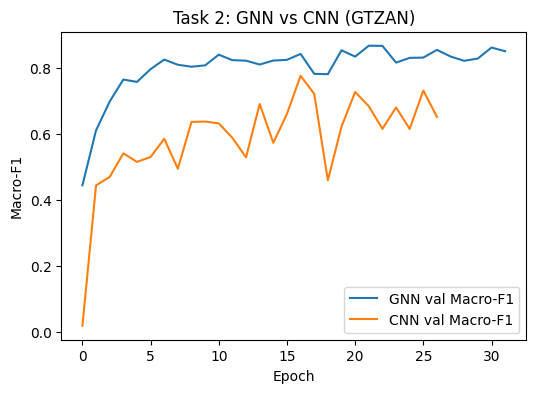

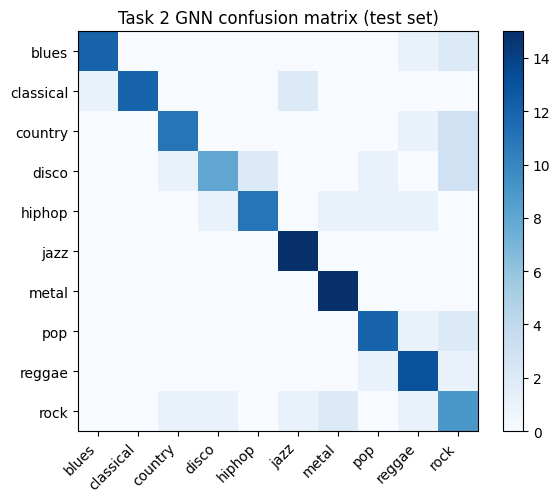

In [ ]:
# ============================================================
# Final held-out TEST evaluation (never touched during training/early stopping)
# ============================================================
_, gnn_test_acc, gnn_test_f1, gnn_probs, gnn_labels = run_gnn_epoch(gnn_model, test_gloader)
_, cnn_test_acc, cnn_test_f1, cnn_probs, cnn_labels = run_cnn_epoch(cnn_model, test_gloader)

# Simple soft-vote ensemble of the two independent views (audio-graph + mel-CNN)
ens_probs = (gnn_probs + cnn_probs) / 2
ens_preds = ens_probs.argmax(1)
ens_acc = accuracy_score(gnn_labels, ens_preds)
ens_f1 = f1_score(gnn_labels, ens_preds, average="macro", zero_division=0)

print("=" * 60)
print("TASK 2 — HELD-OUT TEST RESULTS (GTZAN, 10-way genre classification)")
print("=" * 60)
print(f"GNN (GraphSAGE):   Accuracy={gnn_test_acc:.4f}   Macro-F1={gnn_test_f1:.4f}")
print(f"CNN (mel-spec):    Accuracy={cnn_test_acc:.4f}   Macro-F1={cnn_test_f1:.4f}")
print(f"GNN+CNN ensemble:  Accuracy={ens_acc:.4f}   Macro-F1={ens_f1:.4f}")

plt.figure(figsize=(6, 4))
plt.plot(gnn_hist["val_f1"], label="GNN val Macro-F1")
plt.plot(cnn_hist["val_f1"], label="CNN val Macro-F1")
plt.xlabel("Epoch"); plt.ylabel("Macro-F1"); plt.legend(); plt.title("Task 2: GNN vs CNN (GTZAN)")
plt.savefig("results/plots/task2_curves.png", dpi=120, bbox_inches="tight")
plt.show()

cm = confusion_matrix(gnn_labels, gnn_probs.argmax(1))
plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.xticks(range(NUM_CLASSES), GENRES, rotation=45, ha="right")
plt.yticks(range(NUM_CLASSES), GENRES)
plt.colorbar(); plt.title("Task 2 GNN confusion matrix (test set)")
plt.tight_layout()
plt.savefig("results/plots/task2_confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()